# Clasificación de prendas con Fashion MNIST (TensorFlow)
Red neuronal con dos capas ocultas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Descargar y preparar el dataset

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28) | Prueba: (10000, 28, 28)


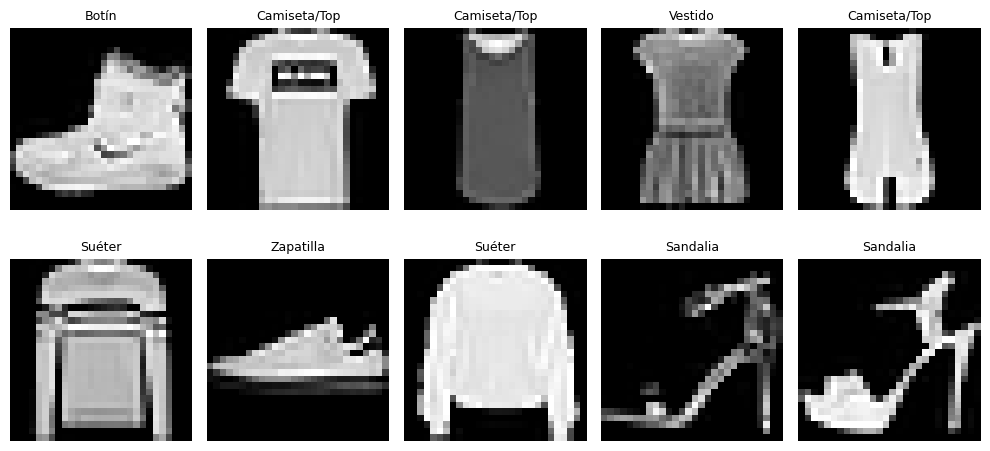

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

print("Entrenamiento:", x_train.shape, "| Prueba:", x_test.shape)

# Normalizar píxeles a [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Definir el modelo (2 capas ocultas)

In [3]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),   # Capa oculta 1
    keras.layers.Dense(64, activation='relu'),    # Capa oculta 2
    keras.layers.Dense(10, activation='softmax')  # Capa de salida
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenar

In [4]:
history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=2)

Epoch 1/15
844/844 - 5s - 6ms/step - accuracy: 0.8200 - loss: 0.5124 - val_accuracy: 0.8618 - val_loss: 0.3898
Epoch 2/15
844/844 - 13s - 15ms/step - accuracy: 0.8633 - loss: 0.3755 - val_accuracy: 0.8632 - val_loss: 0.3654
Epoch 3/15
844/844 - 11s - 14ms/step - accuracy: 0.8762 - loss: 0.3390 - val_accuracy: 0.8578 - val_loss: 0.3954
Epoch 4/15
844/844 - 5s - 6ms/step - accuracy: 0.8836 - loss: 0.3172 - val_accuracy: 0.8672 - val_loss: 0.3685
Epoch 5/15
844/844 - 9s - 11ms/step - accuracy: 0.8917 - loss: 0.2953 - val_accuracy: 0.8763 - val_loss: 0.3313
Epoch 6/15
844/844 - 4s - 5ms/step - accuracy: 0.8967 - loss: 0.2807 - val_accuracy: 0.8840 - val_loss: 0.3259
Epoch 7/15
844/844 - 5s - 6ms/step - accuracy: 0.9009 - loss: 0.2681 - val_accuracy: 0.8822 - val_loss: 0.3341
Epoch 8/15
844/844 - 4s - 4ms/step - accuracy: 0.9046 - loss: 0.2589 - val_accuracy: 0.8827 - val_loss: 0.3328
Epoch 9/15
844/844 - 6s - 7ms/step - accuracy: 0.9069 - loss: 0.2501 - val_accuracy: 0.8847 - val_loss: 0.3

## 4. Probar el modelo (precisión en el conjunto de prueba)

In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Precisión en prueba: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Pérdida en prueba:   {test_loss:.4f}")

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"Precisión final entrenamiento: {train_acc*100:.2f}%")
print(f"Precisión final validación:    {val_acc*100:.2f}%")

Precisión en prueba: 0.8845 (88.45%)
Pérdida en prueba:   0.3470
Precisión final entrenamiento: 92.48%
Precisión final validación:    88.67%


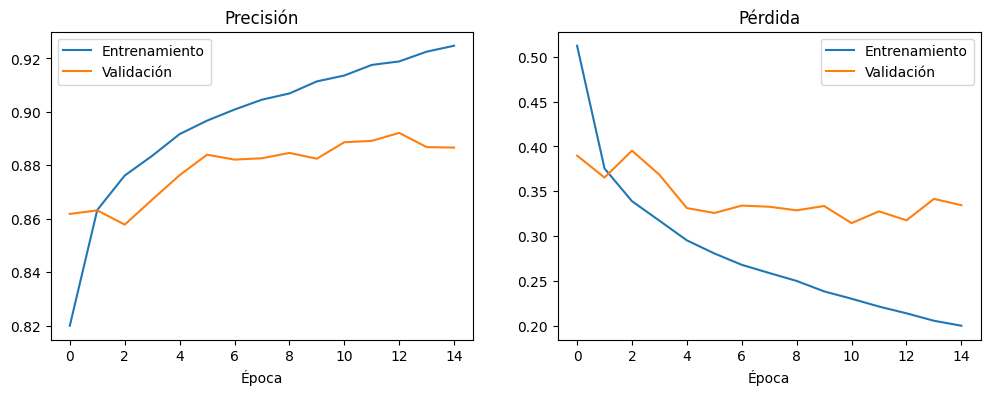

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'], label='Entrenamiento')
ax[0].plot(history.history['val_accuracy'], label='Validación')
ax[0].set_title('Precisión'); ax[0].set_xlabel('Época'); ax[0].legend()
ax[1].plot(history.history['loss'], label='Entrenamiento')
ax[1].plot(history.history['val_loss'], label='Validación')
ax[1].set_title('Pérdida'); ax[1].set_xlabel('Época'); ax[1].legend()
plt.show()

## 5. Análisis de errores

              precision    recall  f1-score   support

Camiseta/Top      0.823     0.834     0.829      1000
    Pantalón      0.990     0.975     0.982      1000
      Suéter      0.781     0.822     0.801      1000
     Vestido      0.866     0.925     0.895      1000
      Abrigo      0.845     0.729     0.783      1000
    Sandalia      0.966     0.969     0.968      1000
      Camisa      0.704     0.733     0.718      1000
   Zapatilla      0.932     0.960     0.946      1000
       Bolso      0.984     0.955     0.969      1000
       Botín      0.968     0.943     0.955      1000

    accuracy                          0.884     10000
   macro avg      0.886     0.885     0.885     10000
weighted avg      0.886     0.884     0.885     10000



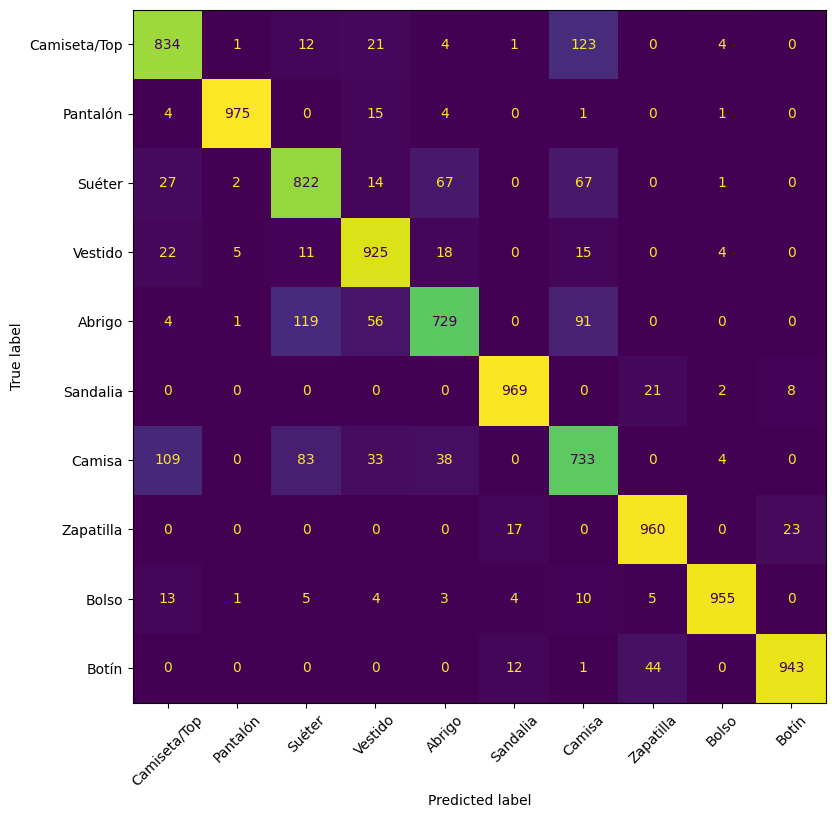

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=class_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.show()

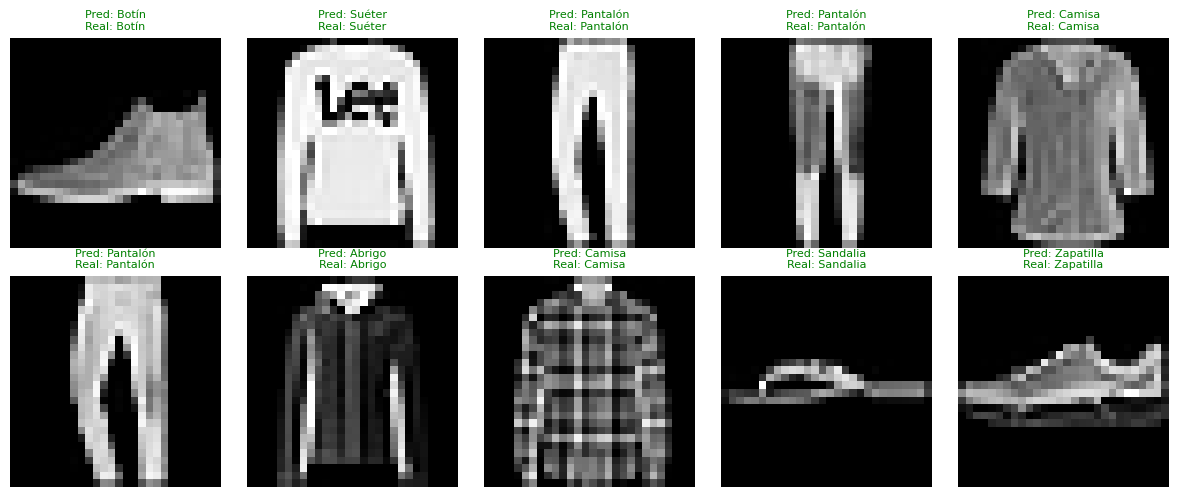

In [8]:
# Algunas predicciones de ejemplo (verde = acierto, rojo = error)
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"Pred: {class_names[y_pred[i]]}\nReal: {class_names[y_test[i]]}",
              color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Conclusiones
1. El modelo obtuvo una precisión de [ ~88-89 ]% sobre el conjunto de prueba, un resultado bueno para una red densa simple, sin capas convolucionales y con pocas épocas de entrenamiento.
2. La precisión de entrenamiento ([ ~93-94 ]%) fue mayor que la de validación/prueba ([ ~88-89 ]%). Esta diferencia indica un leve sobreajuste: el modelo empieza a memorizar los datos de entrenamiento después de cierto número de épocas.
3. Al analizar la matriz de confusión, las clases mejor clasificadas fueron las visualmente distintivas: pantalón, bolso, botín, zapatilla y sandalia (precisión superior al 95% en la mayoría). Las clases con más errores fueron camiseta/top, camisa, suéter y abrigo, que tienen formas muy parecidas y se confunden entre sí, sobre todo la camisa con la camiseta.
